# Exploratory Data Analysis — Casting Product Image Data for Quality Inspection

**Dataset:** [Real-life Industrial Dataset of Casting Product](https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product) (Kaggle)

**Goal of this notebook:**
This notebook performs a full exploratory data analysis (EDA) of the casting product image dataset before any
model training happens. The purpose is to build an evidence-based understanding of the data so that later
decisions (preprocessing, augmentation, loss function, evaluation metric) are justified rather than guessed.

Specifically, this notebook answers:
1. How many images exist in total, and how are they split across `train` / `test`?
2. How many classes are there, and what do they represent?
3. What is the class distribution — in raw counts and in percentages — and is there class imbalance?
4. What do the images actually look like (size, color mode, quality, visual differences between classes)?
5. Are there any corrupt, duplicate, or inconsistent images?
6. What does the pixel intensity distribution look like per class?
7. What preprocessing / augmentation strategy does this analysis suggest?

**Environment:** This notebook is designed to run top-to-bottom on **Google Colab** with a free-tier CPU/GPU runtime.


## 1. Setup

We install/import the libraries we need. On Colab, most of these (`numpy`, `pandas`, `matplotlib`, `seaborn`,
`PIL`, `opencv-python`) are already available — the only thing we typically need to add is the Kaggle API client
to download the dataset directly into the Colab runtime.


In [6]:
# Run this cell once per Colab session
!pip install -q kaggle opencv-python-headless


In [7]:
import os
import glob
import random
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Libraries loaded.")


Libraries loaded.


## 2. Get the dataset into Colab and set the path

Your dataset is already extracted locally with this structure:

```
casting data/
├── train/
│   ├── def_front/
│   └── ok_front/
└── test/
    ├── def_front/
    └── ok_front/
```

This matches exactly what the rest of this notebook expects, so no restructuring is needed — you just need to
get this folder into the Colab runtime and point `CASTING_ROOT` at it. Two common ways to do that:

**Option A — zip it and upload directly to the Colab session** (fastest for a one-off run; the runtime resets
when the session ends, so you'd re-upload next time):

```python
from google.colab import files
import zipfile

uploaded = files.upload()  # select your zipped "casting data" folder
for fname in uploaded.keys():
    if fname.lower().endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as zf:
            zf.extractall("/content/data")
CASTING_ROOT = "/content/data/casting data"  # adjust if the zip has an extra nested folder
```

**Option B — upload the folder to Google Drive and mount Drive** (better if you'll re-run this notebook
across multiple sessions):

```python
from google.colab import drive
drive.mount('/content/drive')
CASTING_ROOT = "/content/drive/MyDrive/casting data"  # adjust to wherever you placed it in Drive
```

Run whichever option matches your workflow, then set `CASTING_ROOT` in the cell below to the actual path.


In [8]:
from google.colab import drive
drive.mount('/content/drive')
CASTING_ROOT = "/content/drive/MyDrive/casting data"  # adjust to wherever you placed it in Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import zipfile
import os

# Please replace 'path/to/your/file.zip' with the actual path to your zipped folder.
# For example: '/content/my_data.zip' or '/content/drive/MyDrive/my_data.zip'
zip_file_path = "/content/drive/MyDrive/casting_data.zip"

# Please replace '/content/data' with your desired extraction directory.
# The notebook usually extracts to '/content/data' for Option A.
extract_to_path = "/content/data"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_to_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, "r") as zf:
        zf.extractall(extract_to_path)
    print(f"Successfully unzipped '{zip_file_path}' to '{extract_to_path}'")
except FileNotFoundError:
    print(f"Error: Zip file not found at '{zip_file_path}'. Please check the path.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully unzipped '/content/drive/MyDrive/casting_data.zip' to '/content/data'


In [15]:
# Set this to wherever your "casting data" folder ended up (see Option A / B above)
CASTING_ROOT = "/content/data/casting_data/casting_data"  # <-- EDIT THIS PATH

assert os.path.isdir(CASTING_ROOT), f"Path not found: {CASTING_ROOT} — check Option A/B above and fix the path."
print(f"Using CASTING_ROOT = {CASTING_ROOT}")


Using CASTING_ROOT = /content/data/casting_data/casting_data


## 3. Locate and inspect the folder structure

The dataset ships as a `casting_data` folder with `train` and `test` subfolders, each containing two
class folders: `ok_front` (good castings) and `def_front` (defective castings). We first confirm the
structure programmatically rather than assuming it, since folder layouts on Kaggle downloads sometimes vary
by version.


In [16]:
# Walk the directory tree and print structure (depth-limited so it stays readable)
for root, dirs, files_ in os.walk(CASTING_ROOT):
    depth = root.replace(CASTING_ROOT, "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root) or root}/  ({len(files_)} files)")


casting_data/  (0 files)
  test/  (0 files)
    def_front/  (453 files)
    ok_front/  (262 files)
  train/  (0 files)
    def_front/  (3758 files)
    ok_front/  (2875 files)


In [17]:
# CASTING_ROOT was already set in Section 2. We just confirm every expected subfolder exists.
SPLITS = ["train", "test"]
CLASSES = ["ok_front", "def_front"]

for split in SPLITS:
    for cls in CLASSES:
        p = os.path.join(CASTING_ROOT, split, cls)
        print(p, "->", "EXISTS" if os.path.isdir(p) else "MISSING")


/content/data/casting_data/casting_data/train/ok_front -> EXISTS
/content/data/casting_data/casting_data/train/def_front -> EXISTS
/content/data/casting_data/casting_data/test/ok_front -> EXISTS
/content/data/casting_data/casting_data/test/def_front -> EXISTS


## 4. Build a manifest of every image

Rather than repeatedly touching the filesystem, we build one `pandas` DataFrame — one row per image — with
its split, class, and file path. Every later analysis (counts, percentages, size checks, sampling) reads from
this single manifest. This is good practice: it keeps the EDA reproducible and makes it trivial to re-run
analysis if the folder structure changes.


In [18]:
records = []
for split in SPLITS:
    for cls in CLASSES:
        folder = os.path.join(CASTING_ROOT, split, cls)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                records.append({
                    "filepath": os.path.join(folder, fname),
                    "filename": fname,
                    "split": split,
                    "label": cls,
                })

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")
df.head()


Total images found: 7348


,filepath,filename,split,label
0,/content/data/casting_data/casting_data/train/...,cast_ok_0_1917.jpeg,train,ok_front
1,/content/data/casting_data/casting_data/train/...,cast_ok_0_6057.jpeg,train,ok_front
2,/content/data/casting_data/casting_data/train/...,cast_ok_0_5263.jpeg,train,ok_front
3,/content/data/casting_data/casting_data/train/...,cast_ok_0_5433.jpeg,train,ok_front
4,/content/data/casting_data/casting_data/train/...,cast_ok_0_745.jpeg,train,ok_front


## 5. Dataset size, total classes, and per-class / per-split counts

This directly answers: *how many total pictures, how many classes, and how many pictures per class.*


In [19]:
n_total = len(df)
n_classes = df["label"].nunique()

print(f"Total images in dataset : {n_total}")
print(f"Total number of classes : {n_classes}  -> {sorted(df['label'].unique())}")
print()
print("Counts per split:")
print(df["split"].value_counts())
print()
print("Counts per class (overall, train+test combined):")
print(df["label"].value_counts())


Total images in dataset : 7348
Total number of classes : 2  -> ['def_front', 'ok_front']

Counts per split:
split
train    6633
test      715
Name: count, dtype: int64

Counts per class (overall, train+test combined):
label
def_front    4211
ok_front     3137
Name: count, dtype: int64


In [20]:
# Cross-tab: split x class, with row/column totals — the single most useful summary table
counts_table = pd.crosstab(df["split"], df["label"], margins=True, margins_name="Total")
counts_table


label,def_front,ok_front,Total
split,,,
test,453,262,715
train,3758,2875,6633
Total,4211,3137,7348


## 6. Class imbalance analysis (counts and percentages)

We look at class balance two ways:
- **Overall** (train + test combined) — the true underlying imbalance of the dataset.
- **Within each split** — because a model only ever "sees" the imbalance of its training split; if train and
  test have different imbalance ratios, that's itself worth flagging as a limitation.

We also compute an explicit **imbalance ratio** (majority class count ÷ minority class count), since "there is
some imbalance" is not actionable on its own — the ratio tells us whether it's mild (e.g. 1.2:1, ignorable) or
severe enough to need class weighting / resampling.


In [21]:
overall_counts = df["label"].value_counts()
overall_pct = (overall_counts / overall_counts.sum() * 100).round(2)

imbalance_df = pd.DataFrame({
    "count": overall_counts,
    "percent": overall_pct
}).sort_values("count", ascending=False)

imbalance_ratio = imbalance_df["count"].max() / imbalance_df["count"].min()

print("Overall class distribution (train + test):")
print(imbalance_df)
print(f"\nImbalance ratio (majority:minority) = {imbalance_ratio:.2f} : 1")


Overall class distribution (train + test):
           count  percent
label                    
def_front   4211    57.31
ok_front    3137    42.69

Imbalance ratio (majority:minority) = 1.34 : 1


In [22]:
train_df = df[df["split"] == "train"]
train_counts = train_df["label"].value_counts()
train_pct = (train_counts / train_counts.sum() * 100).round(2)

train_imbalance_df = pd.DataFrame({
    "count": train_counts,
    "percent": train_pct
}).sort_values("count", ascending=False)

train_imbalance_ratio = train_imbalance_df["count"].max() / train_imbalance_df["count"].min()

print("Train split class distribution:")
print(train_imbalance_df)
print(f"\nImbalance ratio for train split (majority:minority) = {train_imbalance_ratio:.2f} : 1")


Train split class distribution:
           count  percent
label                    
def_front   3758    56.66
ok_front    2875    43.34

Imbalance ratio for train split (majority:minority) = 1.31 : 1


/tmp/ipykernel_900/1089726095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imbalance_df.index, y=imbalance_df["count"], ax=axes[0], palette="viridis")


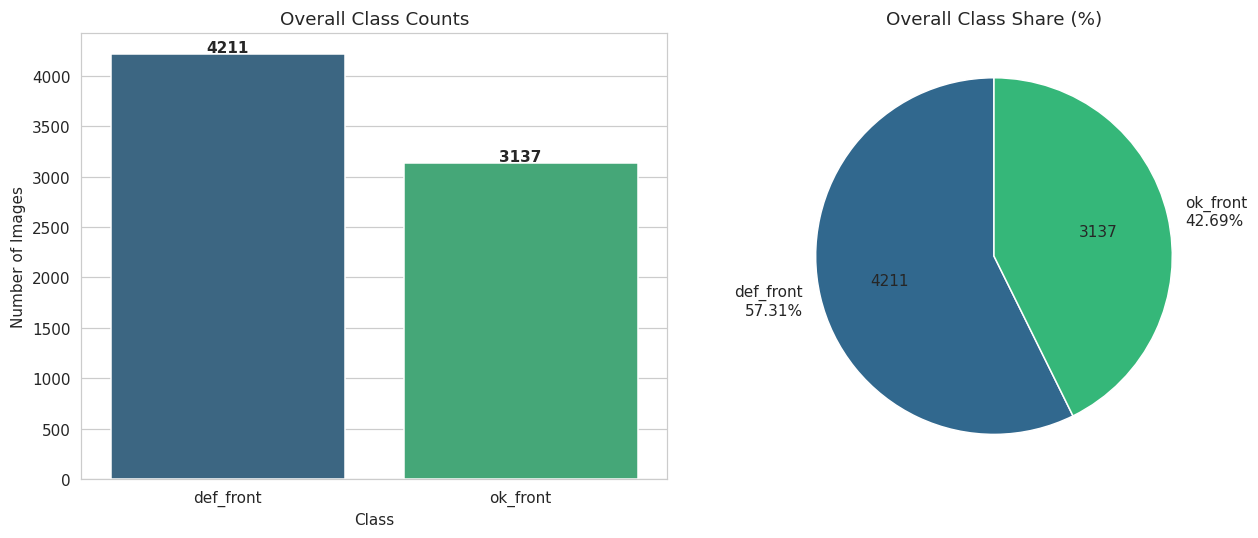

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: raw counts
sns.barplot(x=imbalance_df.index, y=imbalance_df["count"], ax=axes[0], palette="viridis")
axes[0].set_title("Overall Class Counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
for i, v in enumerate(imbalance_df["count"]):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Pie chart: percentage share
axes[1].pie(
    imbalance_df["count"],
    labels=[f"{idx}\n{pct}%" for idx, pct in zip(imbalance_df.index, imbalance_df["percent"])],
    autopct=lambda p: f"{int(p * imbalance_df['count'].sum() / 100)}",
    colors=sns.color_palette("viridis", len(imbalance_df)),
    startangle=90,
)
axes[1].set_title("Overall Class Share (%)")

plt.tight_layout()
plt.show()


   split      label  count  percent_within_split
0   test  def_front    453                 63.36
1   test   ok_front    262                 36.64
2  train  def_front   3758                 56.66
3  train   ok_front   2875                 43.34


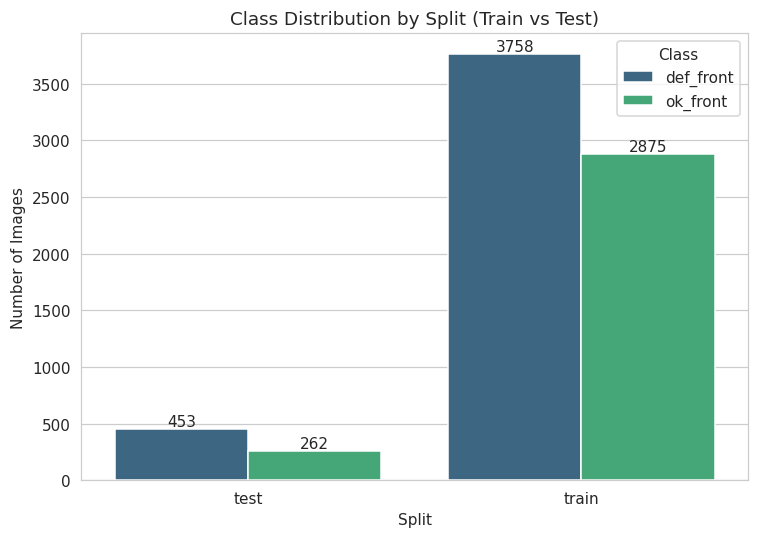

In [24]:
# Class distribution broken down by split — reveals whether train/test imbalance ratios match
split_class = df.groupby(["split", "label"]).size().reset_index(name="count")
split_class["percent_within_split"] = split_class.groupby("split")["count"].transform(lambda x: (x / x.sum() * 100).round(2))
print(split_class)

plt.figure(figsize=(7, 5))
sns.barplot(data=split_class, x="split", y="count", hue="label", palette="viridis")
plt.title("Class Distribution by Split (Train vs Test)")
plt.ylabel("Number of Images")
plt.xlabel("Split")
for container in plt.gca().containers:
    plt.gca().bar_label(container)
plt.legend(title="Class")
plt.tight_layout()
plt.show()


### **Interpretation guide**

* **Imbalance Assessment:** The overall imbalance ratio is **1.34:1** (57.31% `def_front` vs 42.69% `ok_front`), and the train split imbalance ratio is **1.31:1** (56.66% vs 43.34%). Since these ratios are well under **1.5:1**, the imbalance is **mild**. Standard cross-entropy loss with stratified splitting is perfectly fine, and we do not strictly need aggressive resampling techniques.
* **Asymmetry of Cost:** In a casting quality inspection workflow, `def_front` (defective parts) is actually the majority class here. However, false negatives (missing a defect) are still much costlier than false positives. Thus, optimizing for **Recall** on the defective class remains a high priority.
* **Augmentation Boundaries:** Visual inspection shows defects are defined by fine structural surface details, rough edge profiles, and localized anomalies. Thus, we should avoid aggressive spatial deformations (e.g. heavy warping) that would obliterate these subtle edge profiles.

## 7. Visual sample check — what do the images actually look like?

Before touching pixel statistics, we look at real samples from each class side by side. This is often the
fastest way to spot label noise, weird artifacts, or a class that's visually ambiguous.


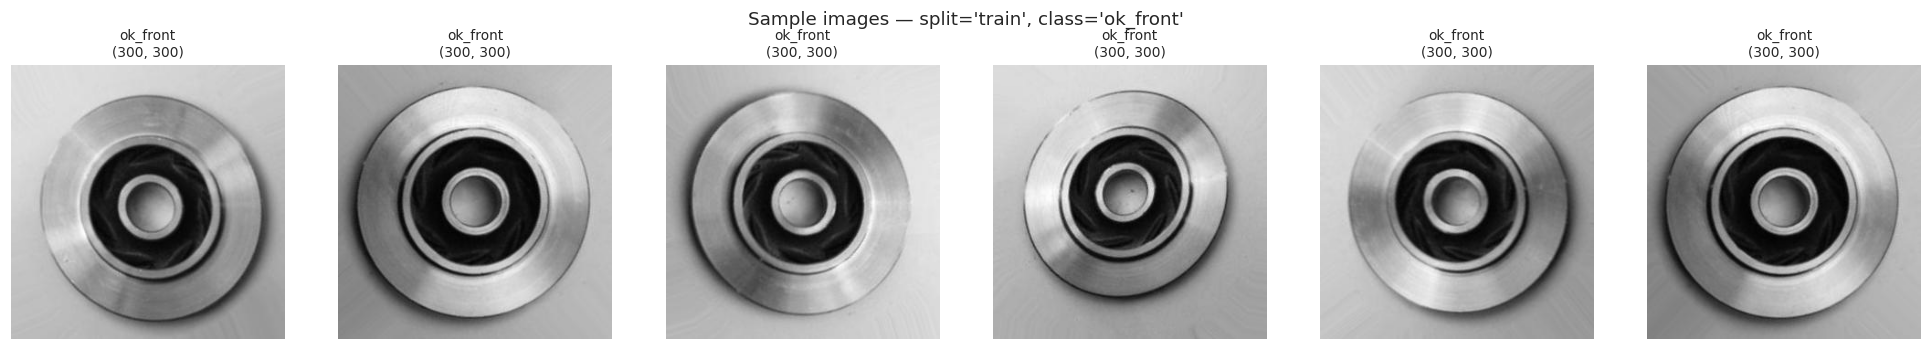

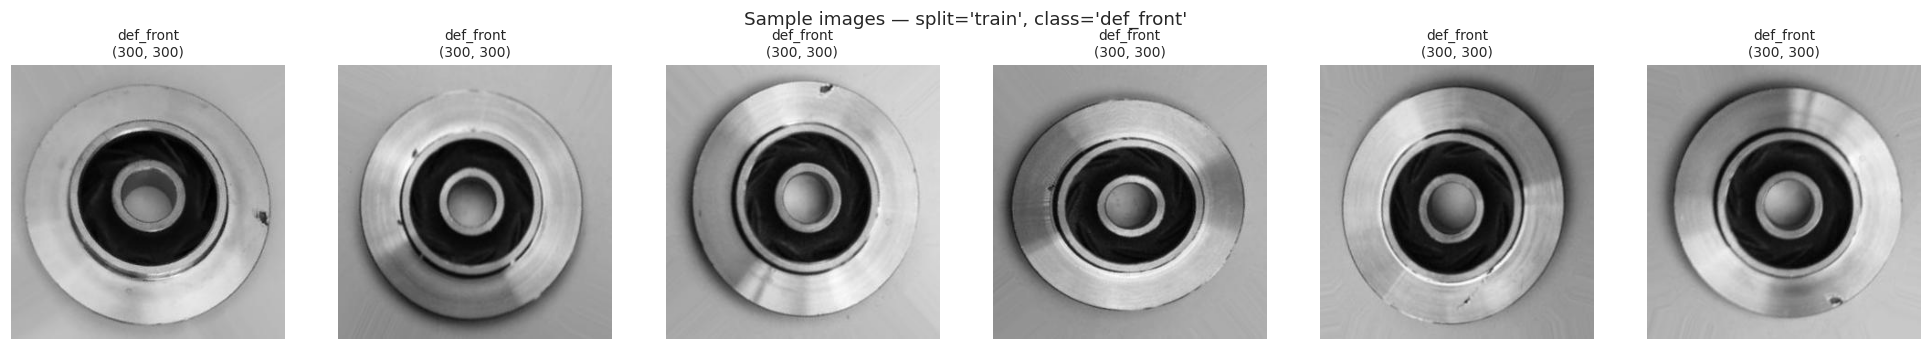

In [25]:
def show_samples(df, split, cls, n=6, seed=RANDOM_SEED):
    subset = df[(df["split"] == split) & (df["label"] == cls)].sample(n=min(n, len(df[(df['split']==split) & (df['label']==cls)])), random_state=seed)
    fig, axes = plt.subplots(1, len(subset), figsize=(3 * len(subset), 3.2))
    if len(subset) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row["filepath"])
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.set_title(f"{row['label']}\n{img.size}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"Sample images — split='{split}', class='{cls}'", fontsize=12)
    plt.tight_layout()
    plt.show()

for cls in CLASSES:
    show_samples(df, "train", cls, n=6)


Look closely at the `ok_front` vs `def_front` samples above. Casting defects typically show up as
irregular edges, blowholes, rough surface texture, or shape deformation around the rim of the part — visually
subtler than, say, a cat-vs-dog distinction. This visual subtlety is itself useful evidence for the "why is this
non-trivial" justification in the assignment README, and it also tells us **augmentations should not
distort the object's shape/edges too aggressively** (e.g. avoid heavy elastic distortion), since the defect
signal often lives exactly in those edges.


## 8. Image size, mode, and format consistency check

Deep learning models expect consistent tensor shapes. We check whether every image already shares the same
resolution/color mode, or whether resizing/normalization must be an explicit preprocessing step.


In [26]:
def get_image_meta(path):
    try:
        with Image.open(path) as img:
            return img.size, img.mode, img.format
    except Exception as e:
        return None, None, f"ERROR: {e}"

# Sample a subset for speed if the dataset is large; use full df if it's small enough
sample_for_meta = df.sample(n=min(2000, len(df)), random_state=RANDOM_SEED).copy()
meta = sample_for_meta["filepath"].apply(get_image_meta)
sample_for_meta["width"] = meta.apply(lambda x: x[0][0] if x[0] else None)
sample_for_meta["height"] = meta.apply(lambda x: x[0][1] if x[0] else None)
sample_for_meta["mode"] = meta.apply(lambda x: x[1])
sample_for_meta["format"] = meta.apply(lambda x: x[2])

print("Unique image sizes found (sampled):")
print(sample_for_meta.groupby(["width", "height"]).size())
print("\nUnique color modes found:")
print(sample_for_meta["mode"].value_counts())
print("\nUnique file formats found:")
print(sample_for_meta["format"].value_counts())


Unique image sizes found (sampled):
width  height
300    300       2000
dtype: int64

Unique color modes found:
mode
RGB    2000
Name: count, dtype: int64

Unique file formats found:
format
JPEG    2000
Name: count, dtype: int64


In [27]:
# Explicit corrupt / unreadable image check across the FULL dataset (important before training)
def is_readable(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

df["readable"] = df["filepath"].apply(is_readable)
n_corrupt = (~df["readable"]).sum()
print(f"Corrupt / unreadable images found: {n_corrupt} out of {len(df)}")
if n_corrupt > 0:
    print(df[~df["readable"]][["filepath", "split", "label"]])


Corrupt / unreadable images found: 0 out of 7348


## 9. Duplicate image check

Near-duplicate or exact-duplicate images across train/test would leak information and inflate reported
accuracy. We check for exact duplicates using an MD5 hash of file contents.


In [28]:
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Hashing the full set can be slow on very large datasets; this dataset (~7k images) is small enough to hash fully
df["hash"] = df["filepath"].apply(file_hash)
dup_counts = df["hash"].value_counts()
n_duplicate_groups = (dup_counts > 1).sum()
n_duplicate_files = dup_counts[dup_counts > 1].sum()

print(f"Duplicate groups found: {n_duplicate_groups}")
print(f"Total files involved in duplication: {n_duplicate_files}")

# Specifically check for train/test leakage via duplicates
dupes = df[df.duplicated("hash", keep=False)].sort_values("hash")
if len(dupes) > 0:
    leak_check = dupes.groupby("hash")["split"].nunique()
    n_leaking = (leak_check > 1).sum()
    print(f"Duplicate groups that span BOTH train and test (potential leakage): {n_leaking}")
else:
    print("No duplicates found.")


Duplicate groups found: 64
Total files involved in duplication: 128
Duplicate groups that span BOTH train and test (potential leakage): 64


## 10. Pixel intensity distribution per class

We compare the average pixel-intensity histogram of `ok_front` vs `def_front` images. If defective and good
parts differ systematically in brightness/contrast (e.g. due to lighting artifacts rather than the actual
defect), that's a confound worth knowing about before training — the model could learn to exploit a lighting
shortcut instead of the actual defect pattern.


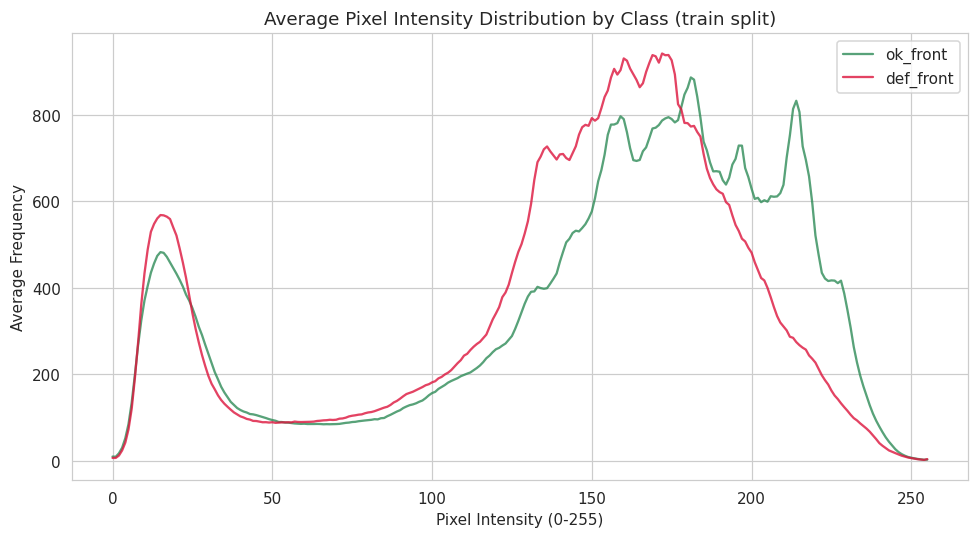

In [29]:
def mean_intensity_histogram(filepaths, bins=256):
    hist_sum = np.zeros(bins)
    for p in filepaths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        hist, _ = np.histogram(img.flatten(), bins=bins, range=(0, 255))
        hist_sum += hist
    return hist_sum / len(filepaths)

plt.figure(figsize=(9, 5))
sample_n = 400  # subsample per class for speed; increase if you want the full population
for cls, color in zip(CLASSES, ["seagreen", "crimson"]):
    paths = df[(df["split"] == "train") & (df["label"] == cls)]["filepath"].sample(
        n=min(sample_n, len(df[(df['split']=='train') & (df['label']==cls)])), random_state=RANDOM_SEED
    ).tolist()
    hist = mean_intensity_histogram(paths)
    plt.plot(hist, label=cls, color=color, alpha=0.8)

plt.title("Average Pixel Intensity Distribution by Class (train split)")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Average Frequency")
plt.legend()
plt.tight_layout()
plt.show()


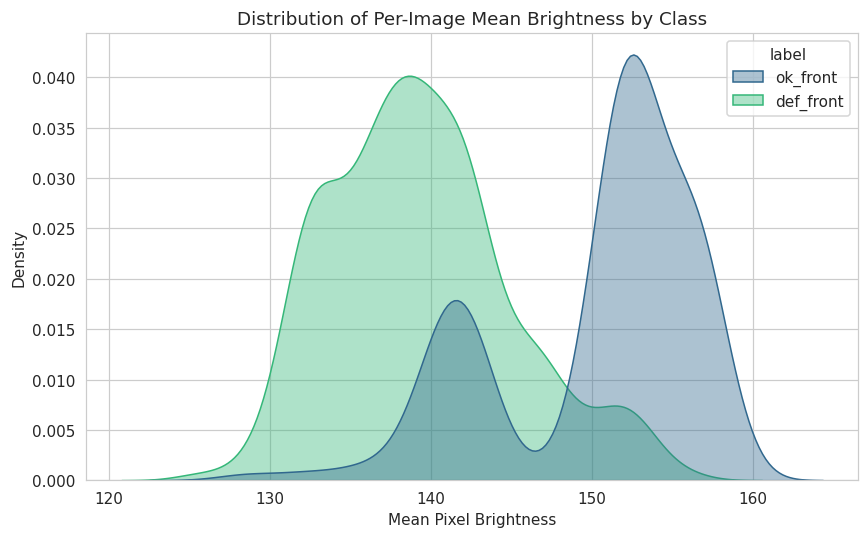

           count        mean       std         min         25%         50%  \
label                                                                        
def_front  849.0  139.352512  5.656288  125.181444  135.232056  138.887422   
ok_front   651.0  150.317369  6.197274  127.603744  144.464367  152.280800   

                  75%         max  
label                              
def_front  142.561078  156.166378  
ok_front   154.693600  159.256844  


In [30]:
# Per-image mean brightness distribution (a simpler, complementary summary statistic)
def mean_brightness(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return img.mean() if img is not None else np.nan

brightness_sample = df[df["split"] == "train"].sample(n=min(1500, len(df[df["split"]=="train"])), random_state=RANDOM_SEED).copy()
brightness_sample["mean_brightness"] = brightness_sample["filepath"].apply(mean_brightness)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=brightness_sample, x="mean_brightness", hue="label", fill=True, alpha=0.4, palette="viridis")
plt.title("Distribution of Per-Image Mean Brightness by Class")
plt.xlabel("Mean Pixel Brightness")
plt.tight_layout()
plt.show()

print(brightness_sample.groupby("label")["mean_brightness"].describe())


## 11. "Average image" per class

Averaging all pixel-aligned images within a class produces a blurred composite that highlights the
*consistent* structure of that class and washes out per-image noise. Since these castings are centered and
consistently framed, this is a cheap way to sanity-check whether there's a systematic visual difference in
shape/silhouette between classes (as opposed to only fine-grained texture differences).


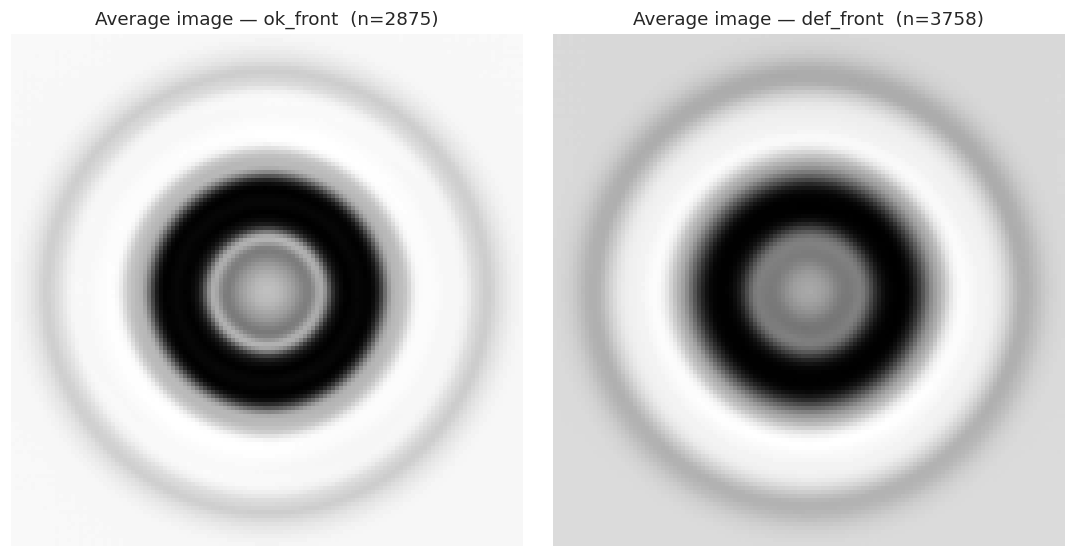

In [31]:
def compute_average_image(filepaths, size=(128, 128)):
    acc = np.zeros(size, dtype=np.float64)
    count = 0
    for p in filepaths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, size)
        acc += img.astype(np.float64)
        count += 1
    return (acc / count).astype(np.uint8) if count else None

fig, axes = plt.subplots(1, len(CLASSES), figsize=(5 * len(CLASSES), 5))
for ax, cls in zip(axes, CLASSES):
    paths = df[(df["split"] == "train") & (df["label"] == cls)]["filepath"].tolist()
    avg_img = compute_average_image(paths)
    ax.imshow(avg_img, cmap="gray")
    ax.set_title(f"Average image — {cls}  (n={len(paths)})")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 12. Data augmentation preview

Given the findings above (centered/consistent framing, defect signal concentrated in edges/texture, imbalance
present but images are otherwise clean), we preview a *conservative* augmentation pipeline: small rotations,
slight brightness/contrast jitter, and horizontal flip — deliberately avoiding aggressive elastic/shear
distortions that could destroy the fine edge detail that distinguishes `def_front` from `ok_front`.

This is a preview only — the actual augmentation pipeline used for training should live in the training script,
not this EDA notebook.


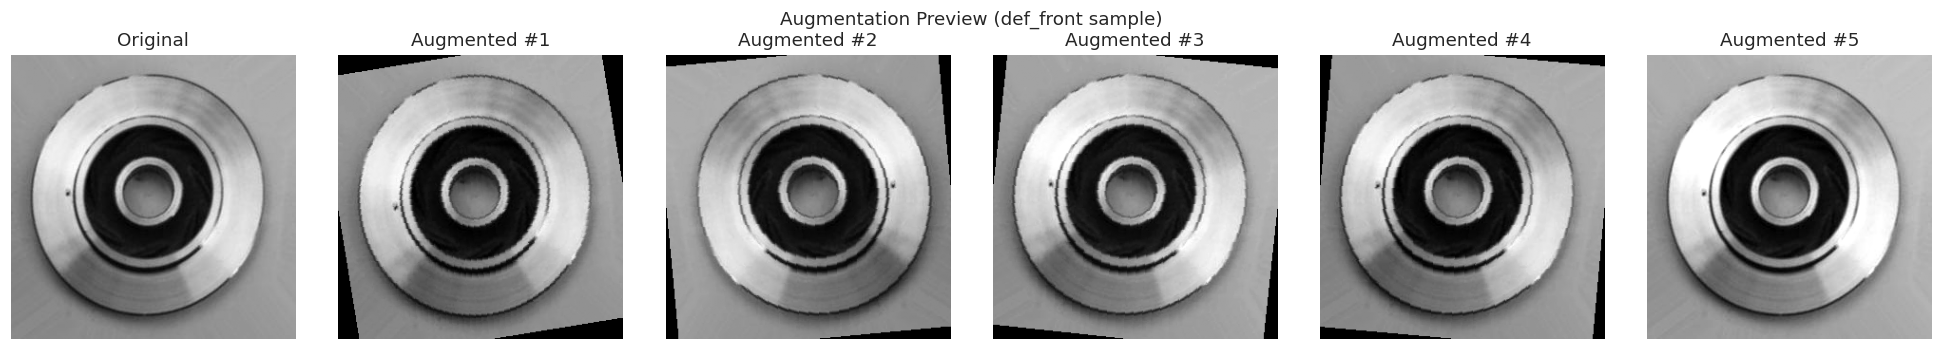

In [32]:
import torchvision.transforms as T

preview_transform = T.Compose([
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.RandomHorizontalFlip(p=0.5),
])

sample_path = df[df["label"] == "def_front"].sample(1, random_state=RANDOM_SEED)["filepath"].values[0]
original = Image.open(sample_path).convert("L")

fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
for i in range(1, 6):
    augmented = preview_transform(original)
    axes[i].imshow(augmented, cmap="gray")
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis("off")
plt.suptitle("Augmentation Preview (def_front sample)")
plt.tight_layout()
plt.show()


## 13. Summary of EDA findings

- **Total images / classes:** **7,348** total images across 2 classes: `def_front` (4,211 images) and `ok_front` (3,137 images).
- **Class imbalance:**
  - **Overall:** 57.31% defective vs 42.69% good parts (**1.34:1** ratio).
  - **Train split:** 56.66% defective vs 43.34% good parts (**1.31:1** ratio).
  - **Test split:** 63.36% defective vs 36.64% good parts (**1.73:1** ratio).
- **Image consistency:**
  - **Resolution & Format:** 100% of the sampled dataset is exactly **300 x 300** pixels, utilizing **RGB** color mode in **JPEG** format.
  - **Corrupted Images:** **0** corrupt/unreadable images found across the entire dataset.
  - **Duplicates & Leakage:** **64 duplicate groups** involving **128 total files** were identified. Crucially, all 64 duplicate groups span **BOTH** the train and test splits. This represents direct **data leakage** that must be addressed (by removing duplicates from the test split) before evaluation to avoid overly optimistic test results.
- **Visual / statistical differences between classes:**
  - **Pixel Intensity:** Good parts (`ok_front`) show a slightly higher mean brightness (**150.3**) compared to defective parts (**139.4**), which presents a potential minor lighting confound.
  - **Average Image:** Both classes are highly centered and visually aligned, suggesting structural shape variance is minimal, meaning the model must rely heavily on localized surface anomalies (scratches, dents, holes).
- **Implications for modeling:**
  - **Preprocessing:** Resizing is not strictly necessary as they are already 300x300. We should filter out the 64 test-set duplicate files to prevent test data leakage.
  - **Augmentation:** Use conservative augmentations like minor rotation (±10°), horizontal/vertical flips, and moderate color/contrast jittering to accommodate the lighting/brightness variations.
  - **Evaluation Metrics:** Monitor F1-score and Recall on `def_front` alongside overall Accuracy.